In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.0001, n_iters=100):
        self.alpha = learning_rate
        self.num_iteration = n_iters
        self.w = 0.0 # theta_1
        self.b = 0.0 # theta_0
        self.SSE_values = []

    def fit(self, x, y):
        w, b = self.w, self.b
        alpha = self.alpha
        
        for i in range(self.num_iteration):
            _y = w * x + b # linear equation

            # Gradients
            delta_w = 2/len(x) * np.sum((_y - y) * x) 
            delta_b = 2/len(x) * np.sum((_y - y) * 1) 

            # Gradient descent - update
            w = w - alpha * (delta_w) 
            b = b - alpha * (delta_b) 

            SSE = (np.sum((_y - y)**2))
            self.SSE_values.append(SSE)

            if (i+1) % 20 == 0:
                print(f"Iteration {i+1}, SSE: {SSE:.2f}")
        
        self.w, self.b = w, b

In [16]:
# Data conversion to numpy arrays
x = np.array([50, 60, 70, 80, 90])
y = np.array([150, 180, 210, 240, 270])

In [17]:
# Execution
model = LinearRegressionGD(learning_rate=0.0001, n_iters=100)
model.fit(x, y)

print(f"\nLearned w (theta_1): {model.w:.4f}")
print(f"Learned b (theta_0): {model.b:.4f}")

Iteration 20, SSE: 0.00
Iteration 40, SSE: 0.00
Iteration 60, SSE: 0.00
Iteration 80, SSE: 0.00
Iteration 100, SSE: 0.00

Learned w (theta_1): 2.9994
Learned b (theta_0): 0.0411


In [18]:
# Predict for 70 m^2
prediction = model.w * 70 + model.b
print(f"Predicted price for 70m^2: {prediction:.2f}")

Predicted price for 70m^2: 210.00


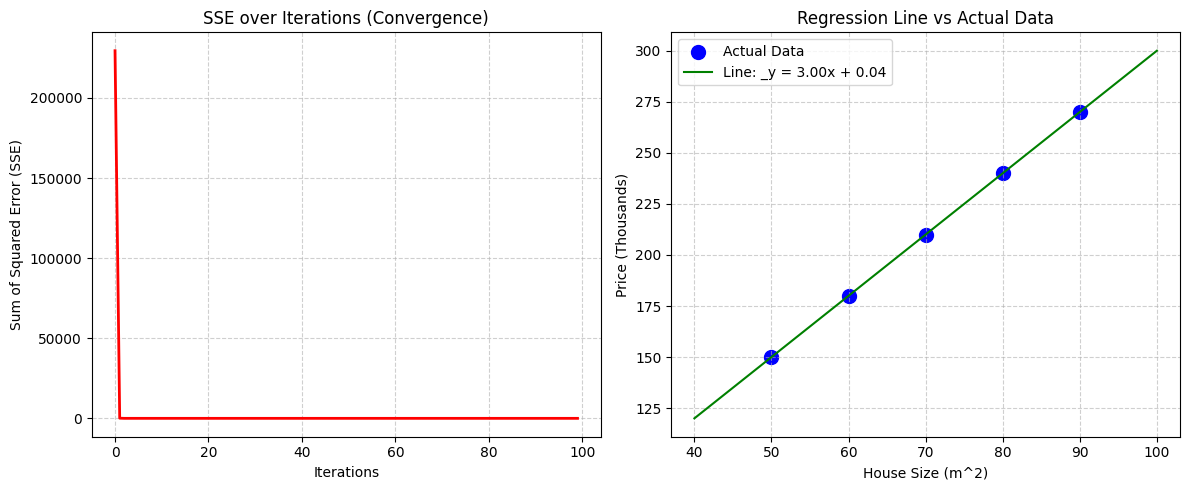

In [19]:
# 1. Visualize SSE over iterations (Learning Curve)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# Access the list from the class instance using model.SSE_values
plt.plot(range(len(model.SSE_values)), model.SSE_values, color='red', linewidth=2)
plt.title('SSE over Iterations (Convergence)')
plt.xlabel('Iterations')
plt.ylabel('Sum of Squared Error (SSE)')
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Plot the regression line with data points
plt.subplot(1, 2, 2)
plt.scatter(x, y, color='blue', label='Actual Data', s=100) # Original data

# Use model.w and model.b for the line
x_line = np.linspace(min(x)-10, max(x)+10, 100)
y_line = model.w * x_line + model.b

plt.plot(x_line, y_line, color='green', label=f'Line: _y = {model.w:.2f}x + {model.b:.2f}')
plt.title('Regression Line vs Actual Data')
plt.xlabel('House Size (m^2)')
plt.ylabel('Price (Thousands)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()